# This notebook

uses pandas.read_csv to open the datafile

for now ill try to divide it up in tasks

## Task one - Exploration of data

Data Exploration (10)

> a. Explore the dataset by displaying the first few rows, summary statistics, and data
types of each column.

> b. Identify missing values, outliers, and unique values in categorical columns.

In [ ]:
# importing stuff and defining the csv https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html
import pandas as pd 
datafile= r"./data/smoking_driking_dataset_Ver01.csv"
df = pd.read_csv(datafile)

In [ ]:
# Table with overall information on the data

print("===== OVERALL INFO =====") # https://www.w3schools.com/python/pandas/ref_df_info.asp

print(f"Observations: {df.shape[0]:,}")
print(f"Variables: {df.shape[1]}")

if df.isnull().sum().sum() == 0:
    print("No missing values in the dataset.\n")
else:
    print(df.isnull().sum()[df.isnull().sum() > 0])

print("Table with columns")
info_table = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values, # Datatype
    "Missing": df.isnull().sum().values, # See if any missing values
    "Unique Values": df.nunique().values # Number of unique values, those with low are liekly categorical values like, male/female, yes/no https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.nunique.html
})

display(info_table)

===== OVERALL INFO =====
Observations: 991,346
Variables: 24
No missing values in the dataset.

Table with columns


,Column,Data Type,Missing,Unique Values
0,sex,str,0,2
1,age,int64,0,14
2,height,int64,0,13
3,weight,int64,0,24
4,waistline,float64,0,737
5,sight_left,float64,0,24
6,sight_right,float64,0,24
7,hear_left,float64,0,2
8,hear_right,float64,0,2
9,SBP,float64,0,171


In [ ]:
print("Example sample of how the data looks like")
df.head()

Example sample of how the data looks like


,sex,age,height,weight,waistline,sight_left,sight_right,hear_left,hear_right,SBP,...,LDL_chole,triglyceride,hemoglobin,urine_protein,serum_creatinine,SGOT_AST,SGOT_ALT,gamma_GTP,SMK_stat_type_cd,DRK_YN
0,Male,35,170,75,90.0,1.0,1.0,1.0,1.0,120.0,...,126.0,92.0,17.1,1.0,1.0,21.0,35.0,40.0,1.0,Y
1,Male,30,180,80,89.0,0.9,1.2,1.0,1.0,130.0,...,148.0,121.0,15.8,1.0,0.9,20.0,36.0,27.0,3.0,N
2,Male,40,165,75,91.0,1.2,1.5,1.0,1.0,120.0,...,74.0,104.0,15.8,1.0,0.9,47.0,32.0,68.0,1.0,N
3,Male,50,175,80,91.0,1.5,1.2,1.0,1.0,145.0,...,104.0,106.0,17.6,1.0,1.1,29.0,34.0,18.0,1.0,N
4,Male,50,165,60,80.0,1.0,1.2,1.0,1.0,138.0,...,117.0,104.0,13.8,1.0,0.8,19.0,12.0,25.0,1.0,N


In [ ]:
# Statistics per column
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,991346.0,47.614491,14.181339,20.0,35.0,45.0,60.0,85.0
height,991346.0,162.240625,9.282957,130.0,155.0,160.0,170.0,190.0
weight,991346.0,63.284050,12.514241,25.0,55.0,60.0,70.0,140.0
waistline,991346.0,81.233358,11.850323,8.0,74.1,81.0,87.8,999.0
sight_left,991346.0,0.980834,0.605949,0.1,0.7,1.0,1.2,9.9
sight_right,991346.0,0.978429,0.604774,0.1,0.7,1.0,1.2,9.9
hear_left,991346.0,1.031495,0.174650,1.0,1.0,1.0,1.0,2.0
hear_right,991346.0,1.030476,0.171892,1.0,1.0,1.0,1.0,2.0
SBP,991346.0,122.432498,14.543148,67.0,112.0,120.0,131.0,273.0
DBP,991346.0,76.052627,9.889365,32.0,70.0,76.0,82.0,185.0


In [ ]:
# AFAIK DRK YN: Do you drink, yes/no? 
# SMK_stat_...:
# Do you smoke? 1: Never smoked, 2 I used to smoke but have now stopped, 3: I currently smoke

# Data on main categories

print("Sex")
print(f"Male: {df['sex'].value_counts()['Male']:,}")
print(f"Female: {df['sex'].value_counts()['Female']:,}")

print("\nAlcohol")
print(f"Drinks: {df['DRK_YN'].value_counts()['Y']:,}")
print(f"Does not drink: {df['DRK_YN'].value_counts()['N']:,}")

smoking = df["SMK_stat_type_cd"].value_counts()

print("\nSmoking")
print(f"Never smoked: {smoking[1.0]:,}")
print(f"Former smoker: {smoking[2.0]:,}")
print(f"Current smoker: {smoking[3.0]:,}")

Sex
Male: 526,415
Female: 464,931

Alcohol
Drinks: 495,488
Does not drink: 495,858

Smoking
Never smoked: 602,441
Former smoker: 174,951
Current smoker: 213,954


In [ ]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 26


In [ ]:
# Summary statistics

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[numeric_cols].describe().T[
    ["min", "25%", "50%", "75%", "max"]
]

,min,25%,50%,75%,max
age,20.0,35.0,45.0,60.0,85.0
height,130.0,155.0,160.0,170.0,190.0
weight,25.0,55.0,60.0,70.0,140.0
waistline,8.0,74.1,81.0,87.8,999.0
sight_left,0.1,0.7,1.0,1.2,9.9
sight_right,0.1,0.7,1.0,1.2,9.9
hear_left,1.0,1.0,1.0,1.0,2.0
hear_right,1.0,1.0,1.0,1.0,2.0
SBP,67.0,112.0,120.0,131.0,273.0
DBP,32.0,70.0,76.0,82.0,185.0


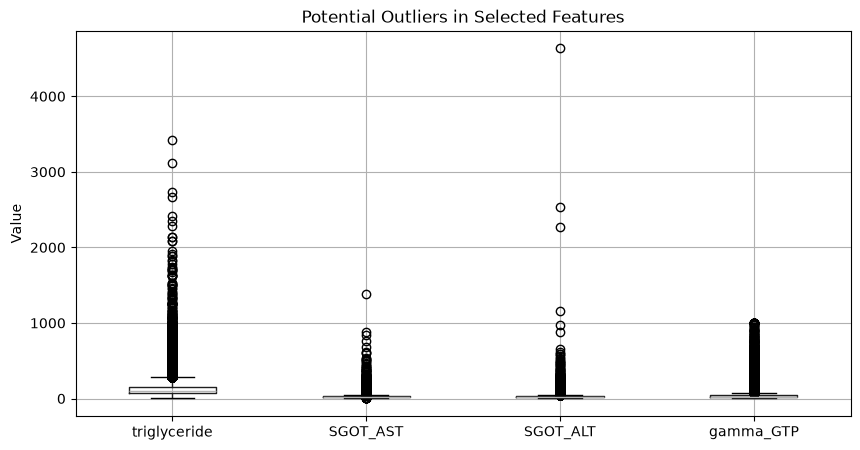

In [ ]:
sample = df.sample(100000, random_state=42)

sample[
    ["triglyceride", "SGOT_AST", "SGOT_ALT", "gamma_GTP"]
].boxplot(figsize=(10, 5))

plt.title("Potential Outliers in Selected Features")
plt.ylabel("Value")
plt.show()

## Task 2 Data Cleaning

In [ ]:
# Missing values
print(f"Missing values: {df.isnull().sum().sum()}")

# Duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

df = df.drop_duplicates()

print(f"Rows after cleaning: {len(df):,}")

Missing values: 0
Duplicate rows: 26
Rows after cleaning: 991,320


## Task 3 outliers something

comparing iqr to z score

"The Interquartile Range (IQR) is a measure of statistical dispersion that describes the spread of the middle 50% of a dataset." https://www.geeksforgeeks.org/dsa/interquartile-range-iqr/

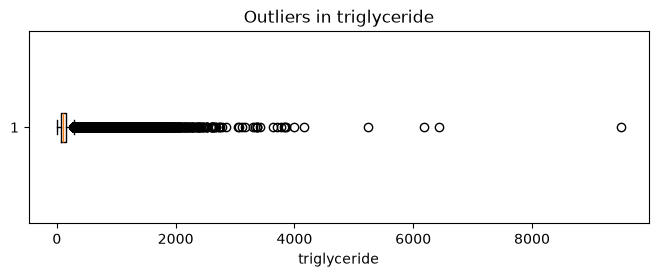

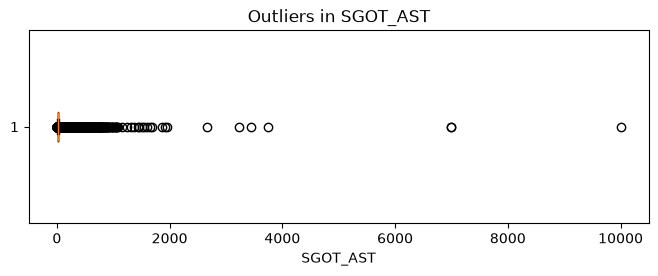

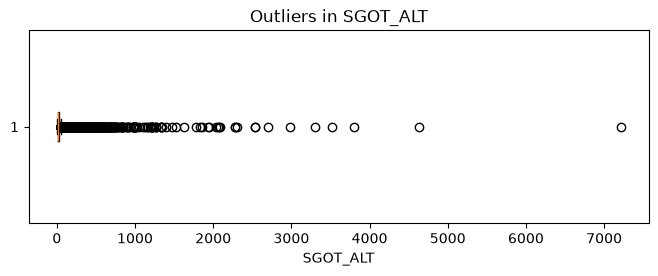

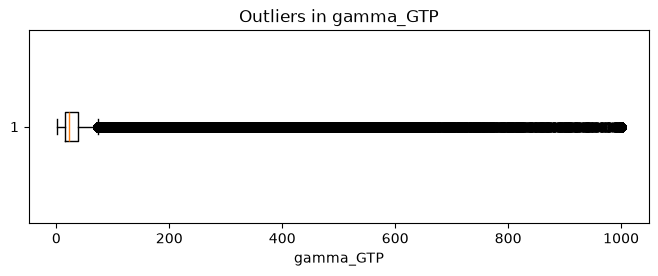

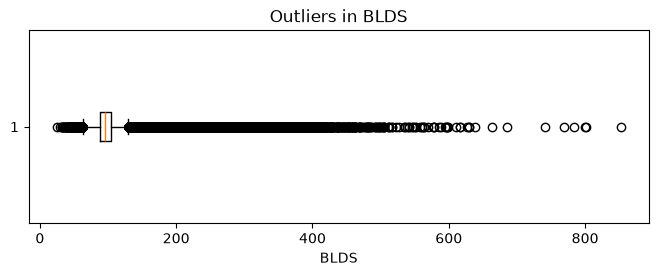

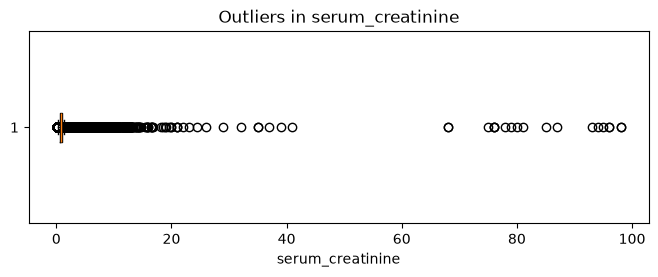

In [ ]:
import matplotlib.pyplot as plt

columns = [
    "triglyceride",
    "SGOT_AST",
    "SGOT_ALT",
    "gamma_GTP",
    "BLDS",
    "serum_creatinine"
]

for col in columns:
    plt.figure(figsize=(8, 2.5))
    plt.boxplot(df[col], orientation="horizontal")
    plt.title(f"Outliers in {col}")
    plt.xlabel(col)
    plt.show()

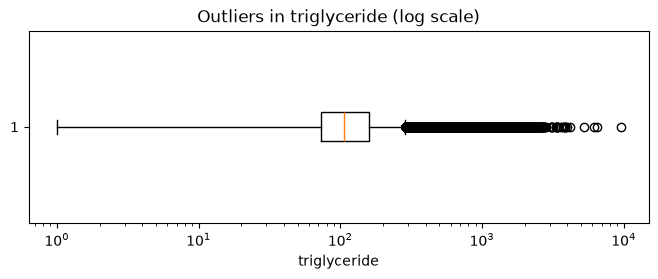

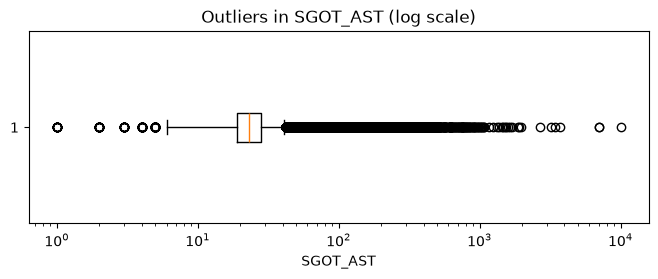

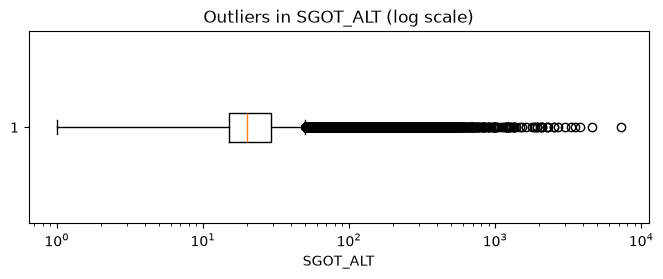

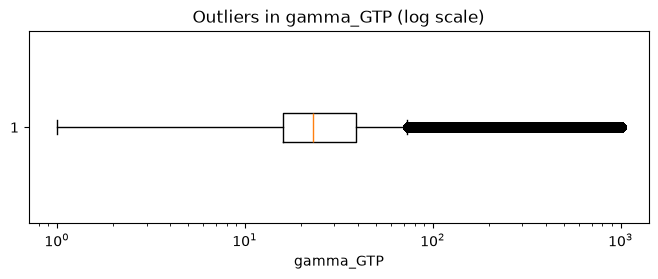

In [ ]:
for col in ["triglyceride", "SGOT_AST", "SGOT_ALT", "gamma_GTP"]:
    plt.figure(figsize=(8, 2.5))
    plt.boxplot(df[col], orientation="horizontal")
    plt.xscale("log")
    plt.title(f"Outliers in {col} (log scale)")
    plt.xlabel(col)
    plt.show()

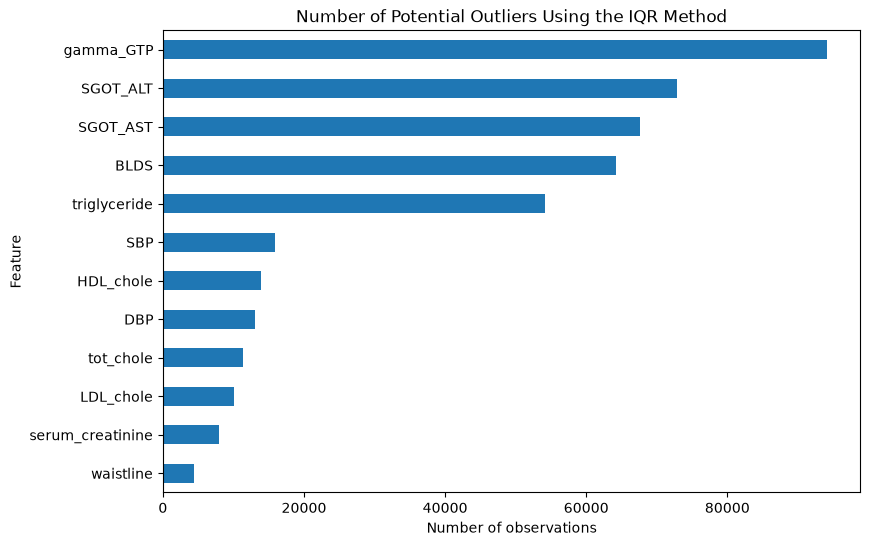

In [ ]:
outlier_counts = {}

columns = [
    "waistline",
    "SBP",
    "DBP",
    "BLDS",
    "tot_chole",
    "HDL_chole",
    "LDL_chole",
    "triglyceride",
    "serum_creatinine",
    "SGOT_AST",
    "SGOT_ALT",
    "gamma_GTP"
]

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_counts[col] = outliers

outlier_counts = (
    pd.Series(outlier_counts)
    .sort_values()
)

outlier_counts.plot(kind="barh", figsize=(9, 6))
plt.title("Number of Potential Outliers Using the IQR Method")
plt.xlabel("Number of observations")
plt.ylabel("Feature")
plt.show()

Q1: 16.0
Q3: 39.0
IQR: 23.0
Upper boundary: 73.5
Maximum: 999.0
Potential outliers: 94142


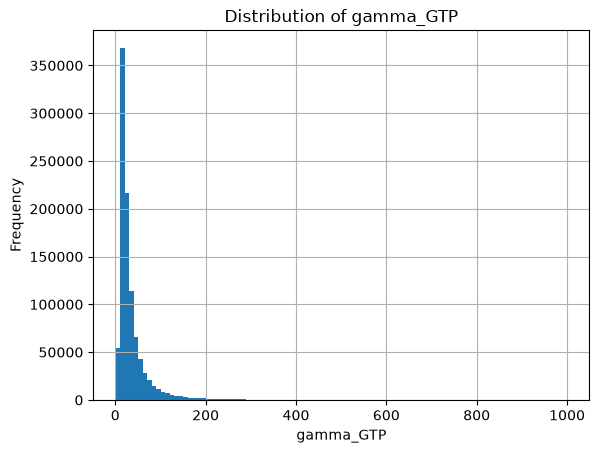

In [ ]:
q1 = df["gamma_GTP"].quantile(0.25)
q3 = df["gamma_GTP"].quantile(0.75)
iqr = q3 - q1

upper = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Upper boundary:", upper)
print("Maximum:", df["gamma_GTP"].max())
print("Potential outliers:", (df["gamma_GTP"] > upper).sum())

df["gamma_GTP"].hist(bins=100)
plt.title("Distribution of gamma_GTP")
plt.xlabel("gamma_GTP")
plt.ylabel("Frequency")
plt.show()

# We can use log transformation here it seems!

,Feature,IQR outliers,Z-score outliers,IQR %,Z-score %
0,waistline,4417,638,0.45,0.06
1,SBP,15836,6423,1.60,0.65
2,DBP,13122,6205,1.32,0.63
3,BLDS,64202,18620,6.48,1.88
4,tot_chole,11298,4937,1.14,0.50
5,HDL_chole,13858,3877,1.40,0.39
6,LDL_chole,10098,4177,1.02,0.42
7,triglyceride,54104,14631,5.46,1.48
8,serum_creatinine,8005,1421,0.81,0.14
9,SGOT_AST,67614,5887,6.82,0.59


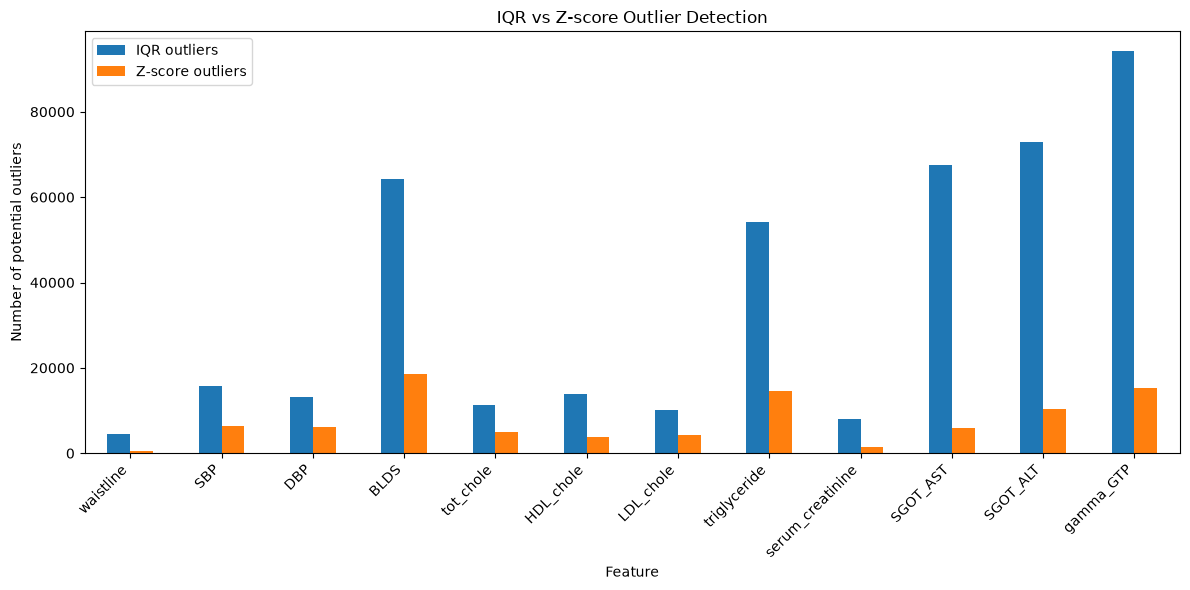

In [ ]:
from scipy.stats import zscore

columns = [
    "waistline",
    "SBP",
    "DBP",
    "BLDS",
    "tot_chole",
    "HDL_chole",
    "LDL_chole",
    "triglyceride",
    "serum_creatinine",
    "SGOT_AST",
    "SGOT_ALT",
    "gamma_GTP"
]

results = []

for col in columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    iqr_count = ((df[col] < lower) | (df[col] > upper)).sum()

    # Z-score
    z = zscore(df[col])
    z_count = (abs(z) > 3).sum()

    results.append({
        "Feature": col,
        "IQR outliers": iqr_count,
        "Z-score outliers": z_count,
        "IQR %": round(iqr_count / len(df) * 100, 2),
        "Z-score %": round(z_count / len(df) * 100, 2)
    })

comparison = pd.DataFrame(results)

display(comparison)

comparison.set_index("Feature")[["IQR outliers", "Z-score outliers"]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylabel("Number of potential outliers")
plt.title("IQR vs Z-score Outlier Detection")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()